# Day 7 EOD: Forty Thousand Zip Codes

Date: 09/09/2026

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base = 'https://eds-217-essential-python.github.io/data/'

zones_2012 = pd.read_csv(base + 'hardiness_zones_2012.csv')
zones_2023 = pd.read_csv(base + 'hardiness_zones_2023.csv')
zipcodes = pd.read_csv(base + 'zip_code_database.csv')

In [2]:
zones_2023['zipcode'] = zones_2023['zipcode'].astype(str).str.zfill(5)
zones_2012['zipcode'] = zones_2012['zipcode'].astype(str).str.zfill(5)
zipcodes['zip'] = zipcodes['zip'].astype(str).str.zfill(5)

### Part 1: 3 Files

How many rows and columns does each of the three tables have? What are the column names of the two zone tables, and are they the same?

In [3]:
print(f"zipcodes: {zipcodes.shape}")
print(f"zones_2012: {zones_2012.shape}")
print(f"zones_2023: {zones_2023.shape}")

zipcodes: (42522, 16)
zones_2012: (40534, 4)
zones_2023: (39921, 4)


In [4]:
zones_2012.head()

,zipcode,zone,trange,zonetitle
0,01001,6a,-10 to -5,6a: -10 to -5
1,01002,5b,-15 to -10,5b: -15 to -10
2,01003,5b,-15 to -10,5b: -15 to -10
3,01004,5b,-15 to -10,5b: -15 to -10
4,01005,5b,-15 to -10,5b: -15 to -10


In [5]:
zones_2023.head()

,zipcode,zone,trange,zonetitle
0,00501,7b,5 to 10,7b: 5 to 10
1,00544,7b,5 to 10,7b: 5 to 10
2,01001,6b,-5 to 0,6b: -5 to 0
3,01002,6a,-10 to -5,6a: -10 to -5
4,01003,6a,-10 to -5,6a: -10 to -5


Run .isnull().sum() on both zone tables. Then look at .head() of either one and say, in one sentence, what zone, trange and zonetitle each hold and which of the three columns is redundant.



In [6]:
print(f"zones_2012: {zones_2012.isnull().sum()}")
print(f"zones_2023: {zones_2023.isnull().sum()}")

# zonetitle appears to be a combination of zones and trange, 
# so is redundant (or makes the others redundant)

zones_2012: zipcode      0
zone         0
trange       0
zonetitle    0
dtype: int64
zones_2023: zipcode      0
zone         0
trange       0
zonetitle    0
dtype: int64


The two files do not have the same number of rows. Before you do anything else, write down two different explanations for that (not that someone made a mistake).



In [7]:
# more zipcodes/zones were added
# zones were subdivided for more accuracy

### Part 2: One table out of three



Add a year column to each zone table, then stack the two of them into one table called zones, using the stacking pattern. How many rows?



In [8]:
zones_2012['year'] = '2012'
zones_2023['year'] = '2023'

In [9]:
zones = pd.concat([zones_2012, zones_2023], ignore_index=True)   

zones.shape 

(80455, 5)

Add trange_min using the line from the Field Note, then confirm it has no nulls and look at its distinct values with .value_counts().sort_index(). In a markdown cell, say what you notice about the spacing of those values and what that means for the phrase “how much warmer”.



In [10]:
zones['trange_min'] = zones['trange'].str.split().str.get(0).astype(int)

In [11]:
zones['trange_min'].isnull().sum()

0

In [12]:
zones['trange_min'].value_counts().sort_index()

trange_min
-40       41
-35      617
-30     1879
-25     3099
-20     4857
-15     7642
-10    11034
-5     10605
 0      8916
 5      7295
 10     6822
 15     5911
 20     3921
 25     4003
 30     2153
 35     1425
 40      216
 45       19
Name: count, dtype: int64

Compute the mean trange_min for each year and report the difference. The difference is the headline number, and the rest of the practice is about how much it is worth.



In [13]:
zones.groupby('year')['trange_min'].mean()

year
2012   -1.899887
2023    1.017259
Name: trange_min, dtype: float64

In [14]:
-1.90 - 1.02

-2.92

Merge zones with zipcodes to attach a state, a latitude and a longitude to every row. The key columns are called different things in the two tables. Compare the row count before and after, then run the merge again with how='left' and find out how many rows failed to match and how many distinct zip codes that is.



In [15]:
inner_merged_zones = pd.merge(zones, zipcodes, left_on='zipcode', right_on='zip', how='inner')    
inner_merged_zones.shape

(80352, 22)

In [16]:
80455 - 80352
# 103 rows were lost

103

In [17]:
left_merged_zones = pd.merge(zones, zipcodes, left_on='zipcode', right_on='zip', how='left')   
left_merged_zones.shape
# no rows were lost with left, vs 103 lost with inner

(80455, 22)

In a markdown cell: 103 rows out of 80,455 did not match, covering 63 zip codes. Is that a number you would fix, a number you would mention, or a number you would ignore? Say which and why. There is more than one defensible answer.



- this is a number I would ignore given that 103/80455 is only about 0.13%
- it is not a statistically significant proportion

### Part 3: The first map



Filter located to the 2023 rows only, then draw a scatter plot with longitude across the bottom, latitude up the side, and hue='trange_min'. Make the figure twelve inches by seven. Label both axes and title it.



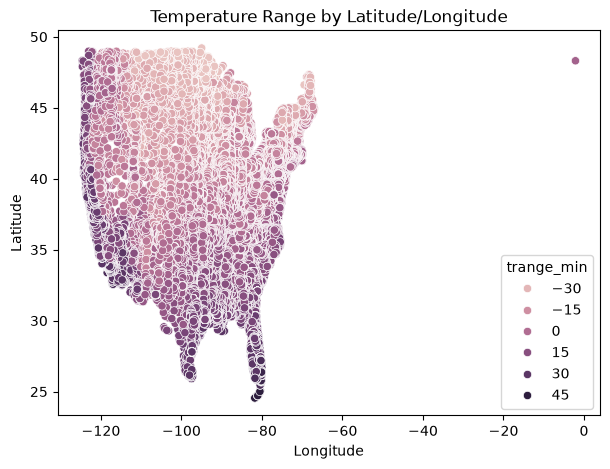

In [18]:
merge_2023 = inner_merged_zones[inner_merged_zones['year'] == '2023']

plt.figure(figsize=(7, 5))

sns.scatterplot(data=merge_2023, x='longitude', y='latitude', hue='trange_min')
# same 
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Temperature Range by Latitude/Longitude')
plt.show()

Describe what is wrong with that figure in a markdown cell.



In [19]:
# dimensions are wrong, scale is weird, random point off to the right side (not in the US)

Find the culprit. Use the filter pattern on located to pull out every row with a longitude greater than −60, and print its zipcode, state, primary_city, latitude and longitude.



In [20]:
find_culprit = merge_2023[merge_2023['longitude'] > -60]
find_culprit

,zipcode,zone,trange,zonetitle,year,trange_min,zip,type,primary_city,acceptable_cities,...,county,timezone,area_codes,latitude,longitude,world_region,country,decommissioned,estimated_population,notes
48834,22350,7b,5 to 10,7b: 5 to 10,2023,5,22350,UNIQUE,Alexandria,NaN,...,NaN,NaN,NaN,48.31,-2.12,NaN,US,0,0,"no NWS data,"


In a markdown cell: that is one zip code, appearing once in each year: two rows out of eighty thousand. Look up roughly where latitude 48.3, longitude −2.1 is. Is the temperature reading wrong, or is something else wrong? What did those two rows do to your figure?



In [ ]:
### these coordinates are in france, so aren't relevant to our data (should not be included).
# those two rows skewed/distorted the figure

Build a table called usa holding only the rows with longitude less than −60, and redraw the 2023 map from it. Then draw the same map for 2012.



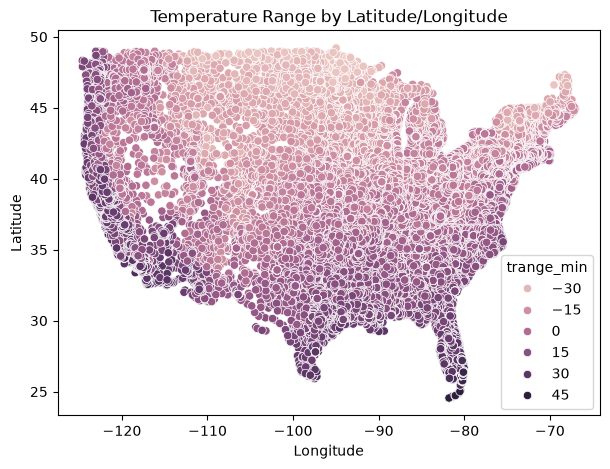

In [23]:
usa = inner_merged_zones[inner_merged_zones['longitude'] < -60]


cleaned_2023 = usa[usa['year'] == '2023']

plt.figure(figsize=(7, 5))

sns.scatterplot(data=cleaned_2023, x='longitude', y='latitude', hue='trange_min')
# same 
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Temperature Range by Latitude/Longitude')
plt.show()

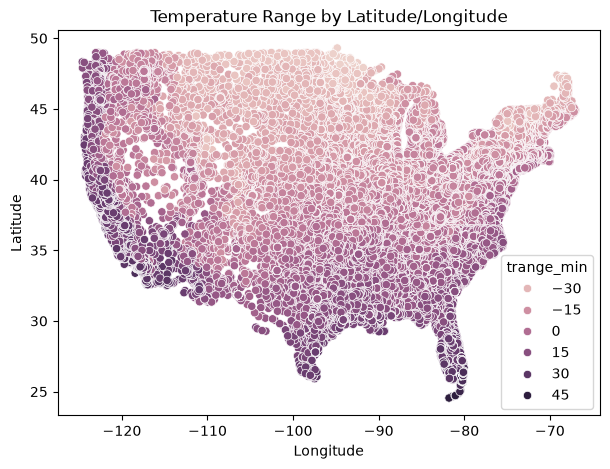

In [24]:
cleaned_2012 = usa[usa['year'] == '2012']

plt.figure(figsize=(7, 5))

sns.scatterplot(data=cleaned_2012, x='longitude', y='latitude', hue='trange_min')
# same 
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Temperature Range by Latitude/Longitude')
plt.show()

You have just drawn a recognizable map of the United States without a mapping library, a projection, or a shapefile. Explain in a markdown cell how that worked here. Then, run usa['state'].nunique() and say which parts of the country are not in these files at all.



In [ ]:
# the map consists of points on a graph, where (x,y) coordinates
# correspond to latitude/longitude pairs.  Since we have data for (almost) 
# all parts of the USA, plotting those points creates a rough outline of the USA

In [26]:
usa['state'].nunique()
# these files do not contain data from Hawaii or Alaska

49

Put the two maps side by side on your screen and try to see the difference between them. Can you?



In [27]:
# the difference is not obvious

### Part 4: What actually changed



Use the pivot pattern to build a table with one row per zip code and one column per year. Index it on ['zipcode', 'state', 'latitude', 'longitude'] so those come along for the ride, put year across the columns and trange_min in the cells, then .reset_index(). What shape is it, and why is that number smaller than 80,000?



In [29]:
pivoted_usa = usa.pivot_table(index=['zipcode', 'state', 'latitude', 'longitude'], columns='year', values='trange_min').reset_index()  
pivoted_usa.shape

(40492, 6)

In [30]:
# there are 40492 rows, which is about half of 80,000 because we now have one
# row per zip code.
# Before, we had two rows per zip code (one for each year)

Add a temp_diff column: the 2023 value minus the 2012 value. Count its nulls and say what a null means here. Then drop those rows.



In [32]:
pivoted_usa['temp_diff'] = pivoted_usa['2023'] - pivoted_usa['2012']
pivoted_usa['temp_diff'].isnull().sum()

634

Draw a histogram of temp_diff. Label it. Then print change['temp_diff'].value_counts().sort_index() and read the two together.

In a markdown cell: what is the most common value, what is the second most common, and how many distinct values are there in total? Given that, is temp_diff a measurement of how much a place warmed, or is it something else? Be precise.




The tails of that histogram are worth a minute. Use the top-N pattern twice to show the five zip codes with the largest increase and the five with the largest decrease, with their states and coordinates.

In a markdown cell: a zip code that moved by 25 or 30 °F has moved five or six whole zones. Do you believe that is a change in the climate? What else could produce it?





temp_diff has too many values to use as a hue= and too few to be interesting as a number. Write a named function called classify_shift that takes one difference and returns 'warmer', 'colder' or 'unchanged', apply it to build a shift column, and count the three categories.



Draw the change map: longitude and latitude again, this time with hue='shift'. Twelve by seven, labelled, titled.



In a markdown cell: Where is the country almost uniformly warmer? Where is it patchy? Where are the 'colder' points, and does their location connect to your answer to question 19?

Then compare this figure with the two maps from question 13, and say in one sentence why the difference had to be computed rather than looked at.





### Part 5: States, and the count column



Group change by state and use .agg(['count', 'mean']) on temp_diff. Show the ten states with the largest mean increase.



Read the count column before you read the mean column. Do any entries surprise you from the top ten? Why?



Build a Series of the ten largest mean increases, sorted, and draw it as horizontal bars using the .values and .index idiom. Label both axes with units and title it.



Now, show the five states with the smallest mean increase instead, with their counts. In a markdown cell: one of those states has more zip codes in it than all but one other state in the file. Does that make its small number more trustworthy or less, and does it make the ranking more interesting or less?

